# Part B - Data Preparation

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load Excel file

df = pd.read_excel("Smart_Outcome_Predictor_Dataset_5200.xlsx")

print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
df.head()

Dataset Shape: (5200, 19)

First 5 Rows:


,student_id,age,country_region,device_type,education_background,course_level,course_category,course_start_date,week_of_year,sessions,time_spent_hours,videos_watched,quiz_attempts,assignments_submitted,forum_posts,avg_quiz_score,attendance_rate,completion_status,final_score
0,700001,32,Europe,Laptop,Undergrad,Intermediate,Business,2024-03-18,12,1,7.6,1,6,1,1,53.3,0.655,0,49.8
1,700002,17,Europe,Laptop,Undergrad,Intermediate,Programming,2024-08-22,34,16,27.2,6,4,7,1,51.5,1.000,1,84.0
2,700003,25,Europe,Mobile,Graduate,Advanced,Programming,2024-09-28,39,6,7.1,16,2,2,0,62.2,0.810,0,62.5
3,700004,26,Asia,Mobile,Undergrad,Beginner,Design,2024-03-09,10,34,22.1,57,9,6,0,59.3,0.875,1,89.5
4,700005,26,Asia,Tablet,WorkingPro,Advanced,Business,2024-03-21,12,22,32.3,41,9,2,0,65.1,0.814,0,67.4


In [3]:
print("Columns in Dataset:\n")

for col in df.columns:
    print(col)

Columns in Dataset:

student_id
age
country_region
device_type
education_background
course_level
course_category
course_start_date
week_of_year
sessions
time_spent_hours
videos_watched
quiz_attempts
assignments_submitted
forum_posts
avg_quiz_score
attendance_rate
completion_status
final_score


In [4]:
df.columns = df.columns.str.strip()

In [ ]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include='object').columns

# Numerical columns
num_imputer = SimpleImputer(strategy='median')
df[num_cols] = num_imputer.fit_transform(df[num_cols])

# Categorical columns
cat_imputer = SimpleImputer(strategy='most_frequent')
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

print("Missing Values:\n")
df.isnull().sum()

Missing Values:

student_id               0
age                      0
country_region           0
device_type              0
education_background     0
course_level             0
course_category          0
course_start_date        0
week_of_year             0
sessions                 0
time_spent_hours         0
videos_watched           0
quiz_attempts            0
assignments_submitted    0
forum_posts              0
avg_quiz_score           0
attendance_rate          0
completion_status        0
final_score              0
dtype: int64


In [6]:
label_encoders = {}

for col in cat_cols:
    
    le = LabelEncoder()
    
    df[col] = le.fit_transform(df[col].astype(str))
    
    label_encoders[col] = le

print("Encoding Completed")

Encoding Completed


In [7]:
df.columns.tolist()

['student_id',
 'age',
 'country_region',
 'device_type',
 'education_background',
 'course_level',
 'course_category',
 'course_start_date',
 'week_of_year',
 'sessions',
 'time_spent_hours',
 'videos_watched',
 'quiz_attempts',
 'assignments_submitted',
 'forum_posts',
 'avg_quiz_score',
 'attendance_rate',
 'completion_status',
 'final_score']

In [8]:
X_cls = df.drop(columns=['completion_status','final_score'])

y_cls = df['completion_status']

print("Classification Features Shape:", X_cls.shape)
print("Classification Target Shape:", y_cls.shape)

Classification Features Shape: (5200, 17)
Classification Target Shape: (5200,)


In [9]:
X_reg = df.drop(columns=['completion_status','final_score'])

y_reg = df['final_score']

print("Regression Features Shape:", X_reg.shape)
print("Regression Target Shape:", y_reg.shape)

Regression Features Shape: (5200, 17)
Regression Target Shape: (5200,)


In [10]:
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls,
    y_cls,
    test_size=0.20,
    random_state=42,
    stratify=y_cls
)

print("X_train_cls:", X_train_cls.shape)
print("X_test_cls :", X_test_cls.shape)

X_train_cls: (4160, 17)
X_test_cls : (1040, 17)


In [11]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

print("X_train_reg:", X_train_reg.shape)
print("X_test_reg :", X_test_reg.shape)

X_train_reg: (4160, 17)
X_test_reg : (1040, 17)


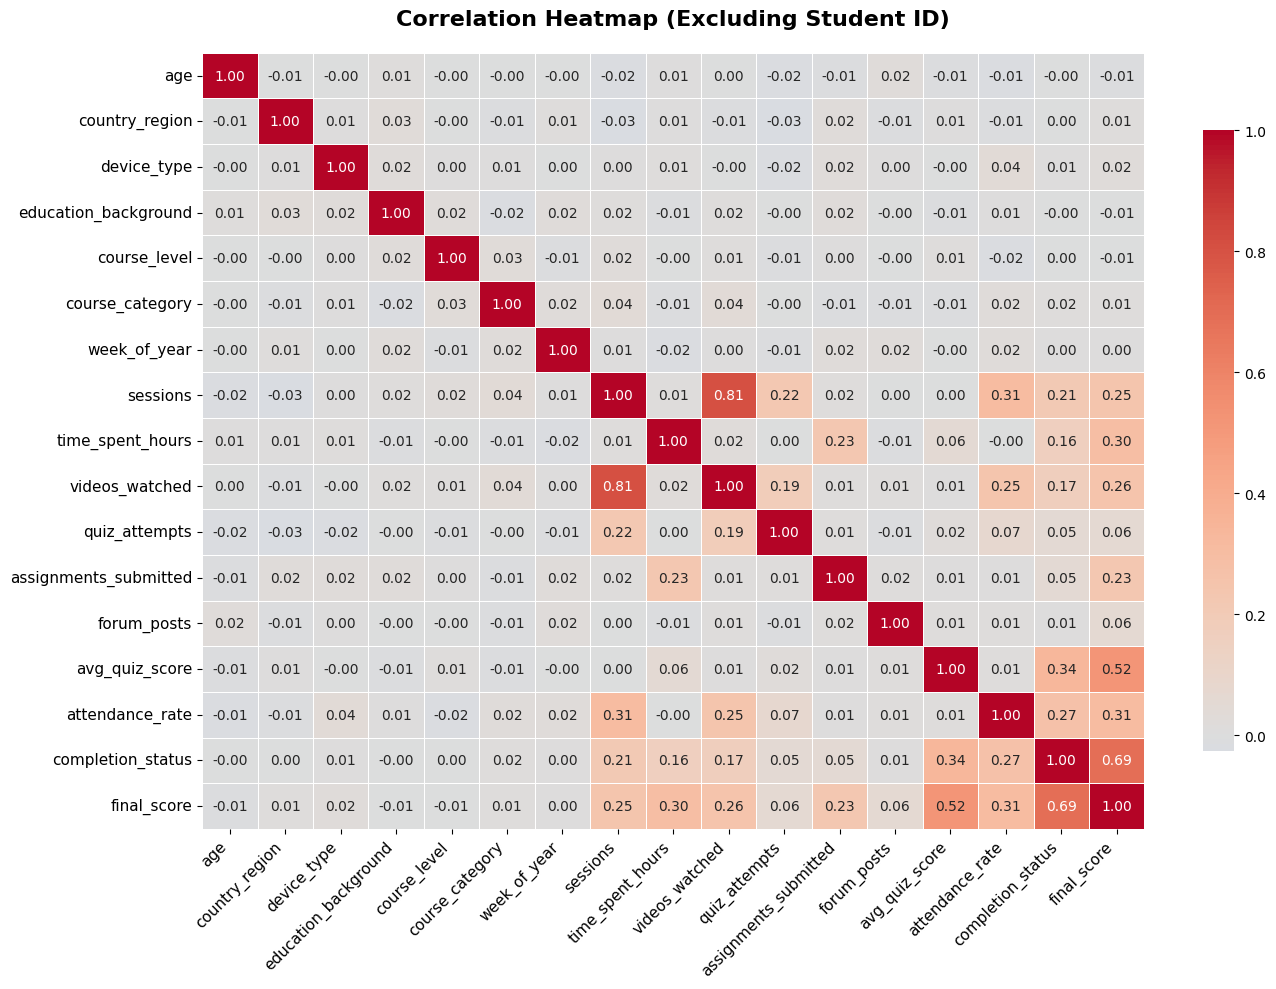

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 10))

# Drop student_id as it has no numeric meaning for correlation
corr_matrix = df.drop(columns=['student_id'], errors='ignore').corr(numeric_only=True)

# Draw the heatmap with annotations and clean styling
sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap='coolwarm', 
    center=0,
    square=False, 
    linewidths=.5, 
    cbar_kws={"shrink": .8},
    annot_kws={"size": 10}
)

plt.title("Correlation Heatmap (Excluding Student ID)", fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()
plt.show()

### Correlation Analysis & Conclusion

Based on the **Correlation Heatmap** above, we can draw the following key insights regarding student performance and engagement:

1. **Strongest Predictors of Academic Outcome (`final_score` & `completion_status`):**
   * **Average Quiz Score (`avg_quiz_score`):** Shows a strong positive correlation of **0.52** with `final_score` and **0.34** with `completion_status`. This indicates that quiz performance is the most critical driver of final academic success.
   * **Attendance Rate (`attendance_rate`):** Positively correlates with `final_score` (**0.31**) and `completion_status` (**0.27**). Students with high attendance consistency perform significantly better.
   * **Time Spent on Course (`time_spent_hours`):** Has a positive correlation of **0.30** with the final score, indicating that total study duration is a solid positive indicator.

2. **Student Activity & Platform Engagement:**
   * **Sessions & Videos Watched:** There is an extremely high correlation of **0.81** between the number of `sessions` and `videos_watched`, showing that study sessions are primarily focused on watching course videos.
   * Both `sessions` (**0.25**) and `videos_watched` (**0.26**) have positive correlations with `final_score`, indicating that general active engagement leads to better grades.
   * **Assignments Submitted (`assignments_submitted`):** Shows a positive correlation of **0.23** with the final score.

3. **Weak or Non-Predictive Features:**
   * **Age** (**-0.01**), **Student ID** (**-0.01**), and **Week of Year** (**0.00**) have virtually zero correlation with either final scores or course completion, meaning demographics and timing do not impact success in this dataset.

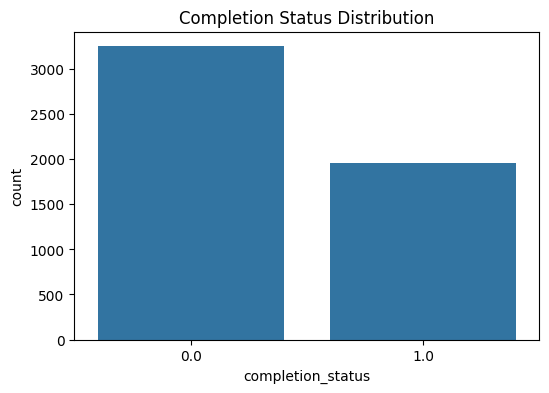

In [13]:
plt.figure(figsize=(6,4))

sns.countplot(x=y_cls)

plt.title("Completion Status Distribution")

plt.show()

In [14]:
print("Classification Training Data")

print(X_train_cls.shape)
print(y_train_cls.shape)

print("\nRegression Training Data")

print(X_train_reg.shape)
print(y_train_reg.shape)

Classification Training Data
(4160, 17)
(4160,)

Regression Training Data
(4160, 17)
(4160,)


## Conclusion 

Dataset loaded successfully.

Missing values handled using Median and Most Frequent strategies.

Categorical columns encoded using LabelEncoder.

Data split into Classification and Regression tasks.

Train-Test split completed successfully.

Dataset is now ready for Bagging, Boosting, Voting, and Stacking models in Part C–G.